### EX: Overfitting vs. Regularization

In this exercise, we will intentionally build a massive, overly complex network on noisy data to force it to overfit. Then, we will build a second model using {term}`Dropout` and {term}`Early Stopping` to prove how regularization saves the mission.

* **Generate Data:** Create a highly noisy, non-linear classification dataset representing chaotic EW signals.

* **Model A (Unregulated):** A massive network allowed to train for too many epochs.

* **Model B (Regulated):** The exact same architecture, but equipped with {term}`Dropout` layers and a Keras {term}`EarlyStopping` callback (which halts training the moment the validation loss starts to increase).

* **Visualize:** Compare the loss curves of both models.

In [ ]:
#Only run this cell after selecting your kernel
!python.exe -m pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas tensorflow

c:\Users\codeh\471Book\jnb_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Unregulated Model...
Training Regularized Model...


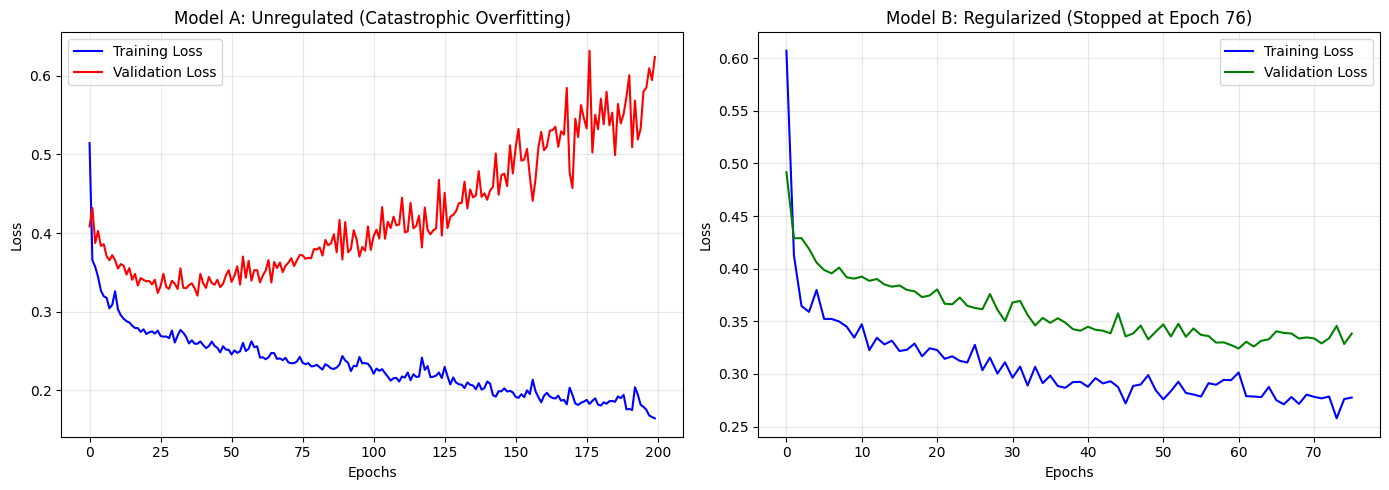

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_moons
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Generate Highly Noisy EW Signal Data
X_ew, y_ew = make_moons(n_samples=800, noise=0.35, random_state=42) # High noise causes overfitting
X_ew_train, X_ew_test, y_ew_train, y_ew_test = train_test_split(X_ew, y_ew, test_size=0.3, random_state=42)

# 2. Build Model A: Massive and Unregulated (The Overfitter)
model_unreg = Sequential([
    Dense(256, activation='relu', input_shape=(2,)),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_unreg.compile(optimizer='adam', loss='binary_crossentropy')

# 3. Build Model B: Regularized (The Operator)
model_reg = Sequential([
    Dense(256, activation='relu', input_shape=(2,)),
    Dropout(0.5), # 50% of neurons randomly disabled every epoch
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model_reg.compile(optimizer='adam', loss='binary_crossentropy')

# Early Stopping: Stop training if validation loss hasn't improved in 15 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 4. Train Both Models
print("Training Unregulated Model...")
hist_unreg = model_unreg.fit(X_ew_train, y_ew_train, epochs=200, validation_split=0.2, verbose=0)

print("Training Regularized Model...")
hist_reg = model_reg.fit(X_ew_train, y_ew_train, epochs=200, validation_split=0.2, callbacks=[early_stop], verbose=0)

# 5. Plot the Divergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Unregulated
axes[0].plot(hist_unreg.history['loss'], label='Training Loss', color='blue')
axes[0].plot(hist_unreg.history['val_loss'], label='Validation Loss', color='red')
axes[0].set_title('Model A: Unregulated (Catastrophic Overfitting)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Regularized
axes[1].plot(hist_reg.history['loss'], label='Training Loss', color='blue')
axes[1].plot(hist_reg.history['val_loss'], label='Validation Loss', color='green')
axes[1].set_title(f'Model B: Regularized (Stopped at Epoch {len(hist_reg.history["loss"])})')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Interpreting the Results

This visualization perfectly captures the greatest threat to a Data Scientist in the Air Force.

Look at **Model A (Unregulated)**. The blue Training Loss line drops straight down to zero—the network thinks it is brilliant. But look at the red Validation Loss line. Around {term}`Epoch` 25, it stops going down and violently U-turns upward! The network has stopped learning the actual EW signals and started purely memorizing the random noise. If deployed, this model would get pilots killed.

Now look at **Model B (Regularized)**. By injecting chaos through {term}`Dropout`, we made it harder for the network to memorize data, keeping the Validation Loss stable. Furthermore, the {term}`Early Stopping` callback acted as an automated commander, recognizing that learning had plateaued and aborting the training process before the network had a chance to overfit, automatically saving the best weights.
